In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

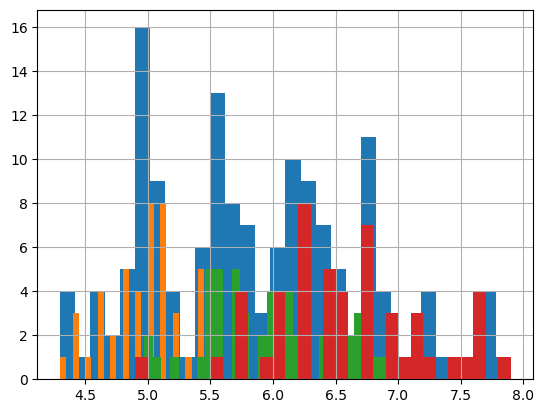

In [2]:
from sklearn import datasets
iris = datasets.load_iris()

iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['sepal length (cm)'].hist(bins=30)

for class_number in np.unique(iris.target):
    plt.figure(1)
    iris_df['sepal length (cm)'].iloc[np.where(iris.target == class_number)[0]].hist(bins=30)

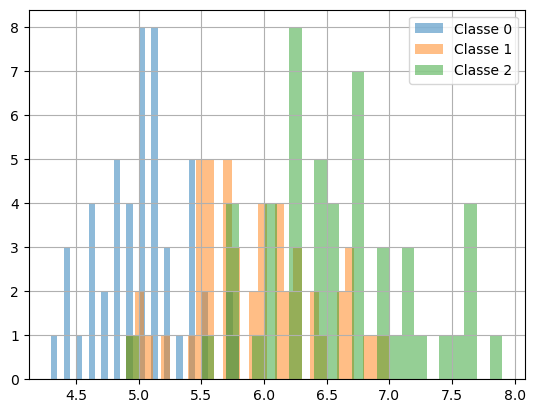

In [3]:
for class_number in np.unique(iris.target):
    iris_df['sepal length (cm)'] \
        .iloc[iris.target == class_number] \
        .hist(bins=30, alpha=0.5, label=f'Classe {class_number}')

plt.legend()

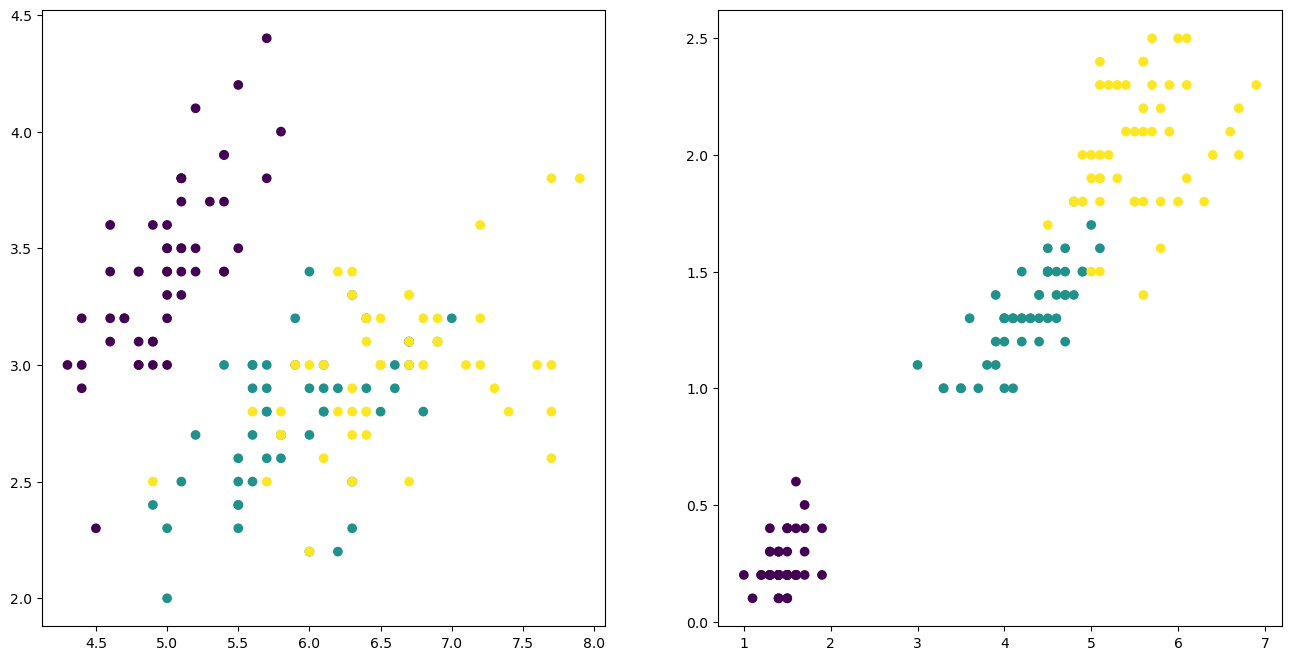

In [4]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
plt.subplot(1, 2, 2)
plt.scatter(iris.data[:, 2], iris.data[:, 3], c=iris.target)

In [5]:
from sklearn.model_selection import train_test_split
X = iris.data[:, :2]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [6]:
from sklearn.svm import SVC
clf = SVC(kernel='linear', random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia: {accuracy * 100:.2f}%')

Acurácia: 84.21%


In [7]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia: {accuracy * 100:.2f}%')

Acurácia: 84.21%


In [10]:
from sklearn import datasets

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

svc_clf = SVC(kernel='linear', random_state=42)
svc_clf.fit(X_train_2, y_train_2)

lr_clf = LogisticRegression(random_state=42).fit(X_train_2, y_train_2)

svc_pred = svc_clf.predict(X_test_2)
lr_pred = lr_clf.predict(X_test_2)

print(f'SVC Acurácia: {accuracy_score(y_test_2, svc_pred) * 100:.2f}%')
print(f'Logistic Regression Acurácia: {accuracy_score(y_test_2, lr_pred) * 100:.2f}%')

print (f'Accuracy of SVC on original test set: {accuracy_score(y_test, svc_clf.predict(X_test))}')


SVC Acurácia: 75.00%
Logistic Regression Acurácia: 75.00%
Accuracy of SVC on original test set: 0.868421052631579


In [11]:
from sklearn.model_selection import cross_val_score

svc_scores = cross_val_score(svc_clf, X_train, y_train, cv=4)
svc_scores

array([0.71428571, 0.78571429, 0.78571429, 0.75      ])

In [13]:
lr_scores = cross_val_score(lr_clf, X_train, y_train, cv=4)
print("Average SVC scores: ", lr_scores.mean())
print("Standard Deviation of SVC scores: ", lr_scores.std())

Average SVC scores:  0.7767857142857143
Standard Deviation of SVC scores:  0.05282214092053226
